# HOuse Model

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression 
import warnings
warnings.filterwarnings('ignore')

# DATA LOAD -  DATA CLean

In [2]:
df = pd.read_csv('kc_house_data.csv')


In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


# EDA

In [4]:
col =['price', 'bedrooms' , 'bathrooms' , 'sqft_living' , 'sqft_lot' ,'floors']

In [5]:
df_clean =df[col]

In [6]:
df_clean.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors
0,221900.0,3,1.00,1180,5650,1.0
1,538000.0,3,2.25,2570,7242,2.0
2,180000.0,2,1.00,770,10000,1.0
3,604000.0,4,3.00,1960,5000,1.0
4,510000.0,3,2.00,1680,8080,1.0


In [7]:
df_clean.isna().sum()

price          0
bedrooms       0
bathrooms      0
sqft_living    0
sqft_lot       0
floors         0
dtype: int64

price , bedrooms , bathrooms , sqft_living , 

sqft_lot , floors , 

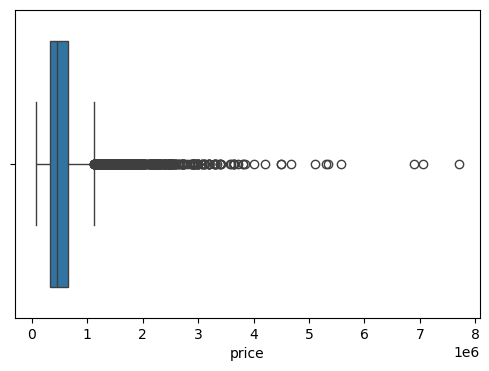

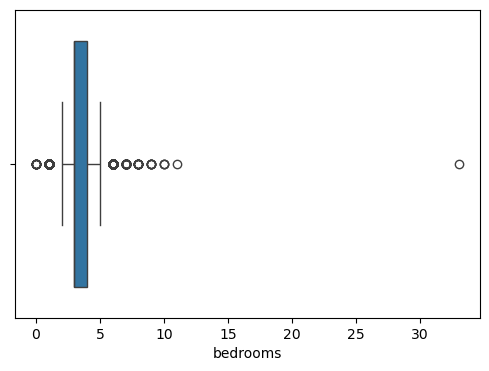

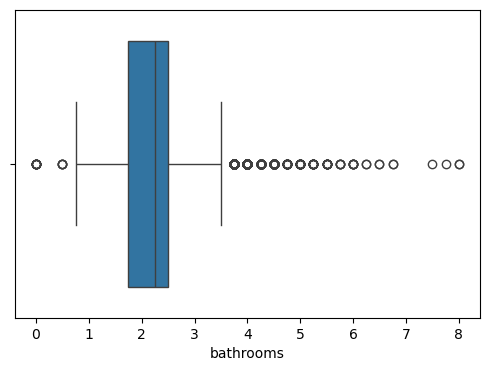

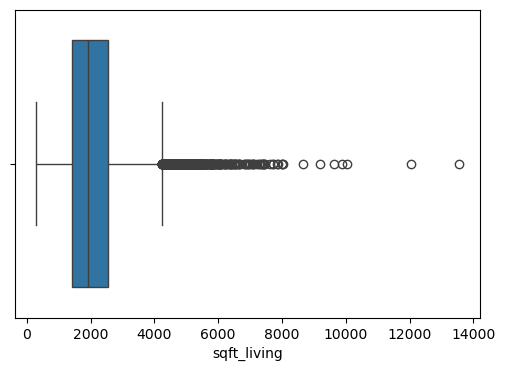

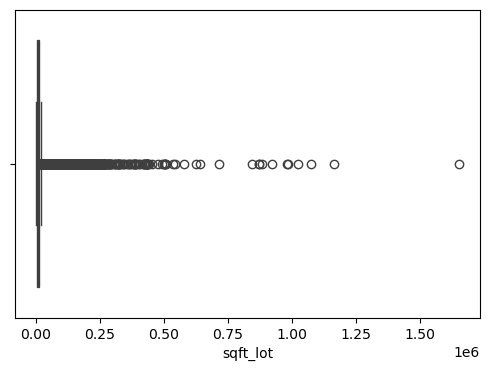

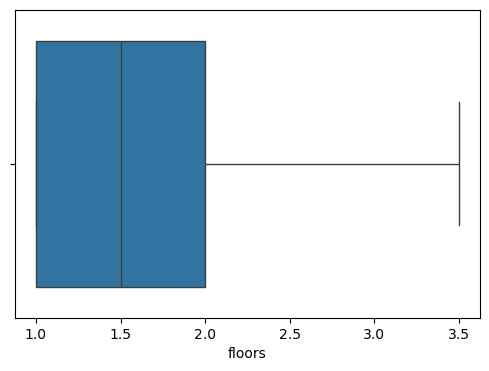

In [8]:
col =['price', 'bedrooms' , 'bathrooms' , 'sqft_living' , 'sqft_lot' ,'floors']
for i in col:
    print(i , end = " , ")
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[i])

In [9]:
df_clean.duplicated().sum()

np.int64(10)

In [10]:
df_clean.drop_duplicates(inplace=True)
df_clean.duplicated().sum()

np.int64(0)

# Remove Outliers

In [11]:
col =['bedrooms' , 'bathrooms' , 'sqft_living' , 'sqft_lot' ,'floors']

for col in col:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # print("value :",df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)])
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]


price , bedrooms , bathrooms , sqft_living , sqft_lot , 

floors , 

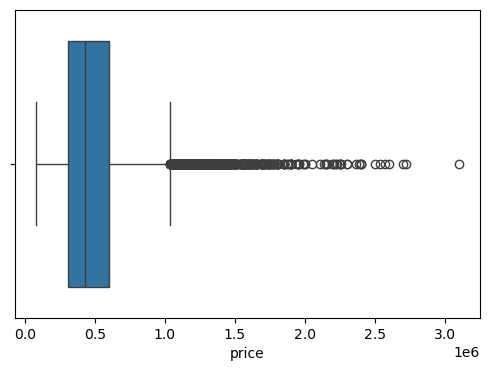

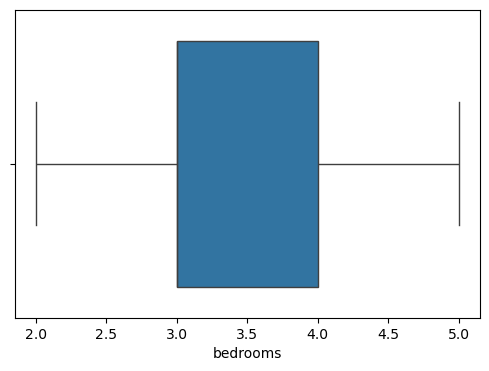

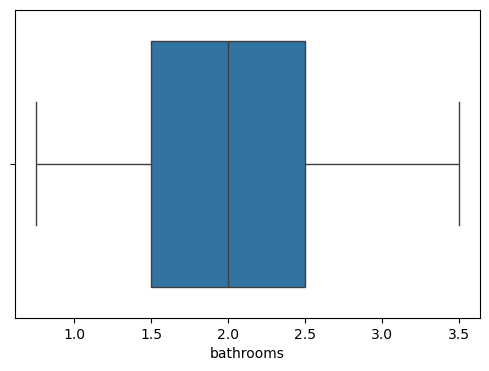

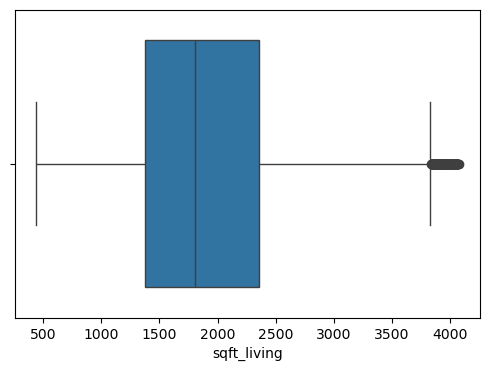

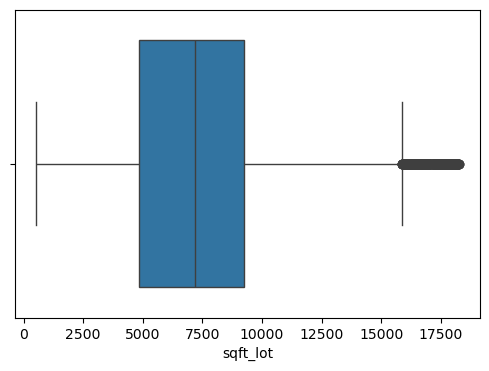

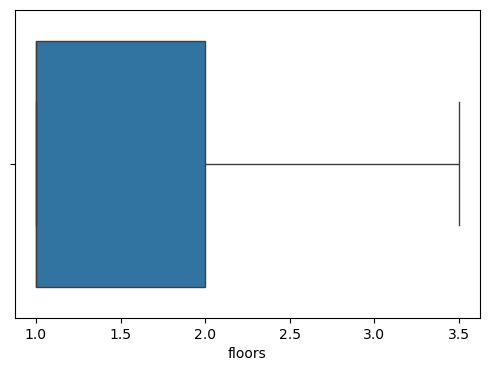

In [12]:
col =['price','bedrooms' , 'bathrooms' , 'sqft_living' , 'sqft_lot' ,'floors']
for i in col:
    print(i , end = " , ")
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[i])

In [13]:
df_clean.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors
0,221900.0,3,1.00,1180,5650,1.0
1,538000.0,3,2.25,2570,7242,2.0
2,180000.0,2,1.00,770,10000,1.0
3,604000.0,4,3.00,1960,5000,1.0
4,510000.0,3,2.00,1680,8080,1.0


<Axes: >

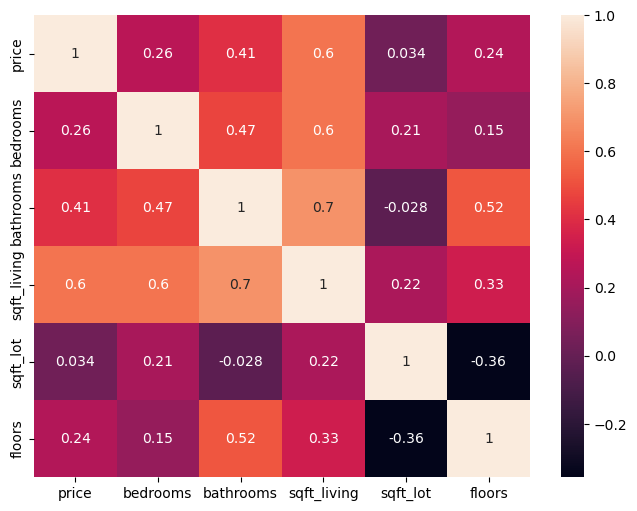

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(numeric_only=True),annot=True)

# Regression Model

--- Linear Regression Evaluation ---
Mean Squared Error: 40838164968.46
Root Mean Squared Error: 202084.55
R2 Score: 0.3967
Slope (Coefficients): [-4.44884986e+04 -1.86604815e+04  2.71979736e+02 -7.69783888e+00
  1.68183403e+03]
Intercept: 204737.15

--- Decision Tree Regressor Evaluation ---
Mean Squared Error: 40459478926.64
Root Mean Squared Error: 201145.42
R2 Score: 0.4023

Predicted Price (Linear Regression) for user input: ₹541102.81


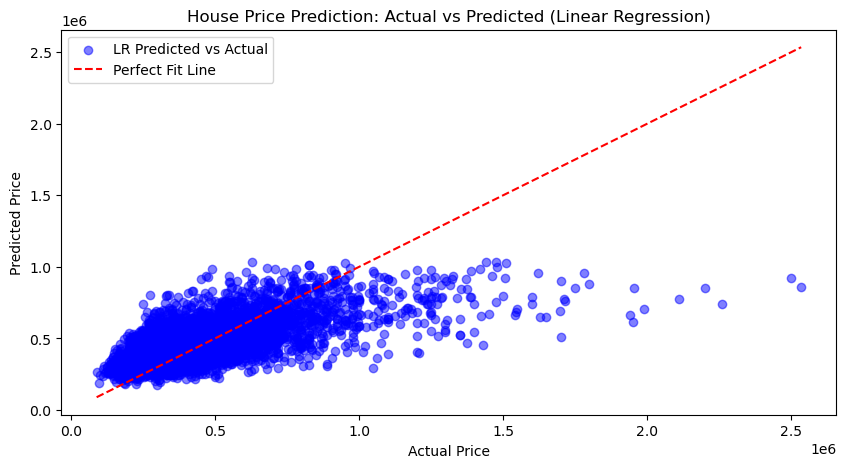

In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error, r2_score 
import warnings
warnings.filterwarnings('ignore')

# Features and Target
X = df_clean[["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors"]]
y = df_clean["price"]

# 1. Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Models (Linear Regression & Decision Tree)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# 3. Predict on Test Set
lr_preds = lr_model.predict(X_test)
dt_preds = dt_model.predict(X_test)

# 4. Evaluate Models
lr_mse = mean_squared_error(y_test, lr_preds)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_preds)

dt_mse = mean_squared_error(y_test, dt_preds)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_preds)

print("--- Linear Regression Evaluation ---")
print(f"Mean Squared Error: {lr_mse:.2f}")
print(f"Root Mean Squared Error: {lr_rmse:.2f}")
print(f"R2 Score: {lr_r2:.4f}")
print(f"Slope (Coefficients): {lr_model.coef_}")
print(f"Intercept: {lr_model.intercept_:.2f}")

print("\n--- Decision Tree Regressor Evaluation ---")
print(f"Mean Squared Error: {dt_mse:.2f}")
print(f"Root Mean Squared Error: {dt_rmse:.2f}")
print(f"R2 Score: {dt_r2:.4f}")

# 5. Non-blocking user input section
try:
    bedrooms_in = input("Enter number of bedrooms: ")
    bedrooms = int(bedrooms_in) if bedrooms_in else 3
    bathrooms_in = input("Enter number of bathrooms: ")
    bathrooms = float(bathrooms_in) if bathrooms_in else 2.0
    sqft_living_in = input("Enter living area (sqft): ")
    sqft_living = int(sqft_living_in) if sqft_living_in else 2000
    sqft_lot_in = input("Enter lot area (sqft): ")
    sqft_lot = int(sqft_lot_in) if sqft_lot_in else 5000
    floors_in = input("Enter number of floors: ")
    floors = float(floors_in) if floors_in else 1.0
except:
    bedrooms, bathrooms, sqft_living, sqft_lot, floors = 3, 2.0, 2000, 5000, 1.0

price_pred = lr_model.predict([[bedrooms, bathrooms, sqft_living, sqft_lot, floors]])
print(f"\nPredicted Price (Linear Regression) for user input: ₹{price_pred[0]:.2f}")

# 6. Plotting the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, lr_preds, color='blue', alpha=0.5, label='LR Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Fit Line')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("House Price Prediction: Actual vs Predicted (Linear Regression)")
plt.legend()
plt.show()


In [16]:
df_clean.to_csv("kc_house_clean_data.csv", index=False)

In [17]:
df_clean.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors'], dtype='object')